<a href="https://colab.research.google.com/github/HopeFullDev/Colab/blob/ACPS/Assign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Data Exploration

## Pesticide

In [3]:
pest_df = pd.read_csv('/content/drive/MyDrive/Classroom/CS546-2025/pesticides.csv')
pest_df.head()

,Unnamed: 0,Domain,Area,Element,Item,Year,Unit,Value
0,0,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1990,tonnes,121
1,1,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1991,tonnes,121
2,2,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1992,tonnes,121
3,3,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1993,tonnes,121
4,4,Pesticides Use,Albania,Agricultural Use,Pesticides (total),1994,tonnes,201


In [4]:
# prompt: Using dataframe pest_df: explore the data frame in different ways

# Display the first few rows of the dataframe
print(pest_df.head())

# Get some basic statistics about the numerical columns
print(pest_df.describe())

# Display the data types of each column
print(pest_df.dtypes)

# Count the number of unique values in each categorical column
for col in pest_df.select_dtypes(include=['category', 'object']):
    print(f'{col}: {pest_df[col].nunique()} unique values')

# Group data by 'Area' and calculate the sum of 'Value' for each area
area_value_sum = pest_df.groupby('Area')['Value'].sum()
print(area_value_sum)

# Group data by 'Year' and calculate the mean of 'Value' for each year
year_value_mean = pest_df.groupby('Year')['Value'].mean()
year_value_mean


   Unnamed: 0          Domain     Area           Element                Item  \
0           0  Pesticides Use  Albania  Agricultural Use  Pesticides (total)   
1           1  Pesticides Use  Albania  Agricultural Use  Pesticides (total)   
2           2  Pesticides Use  Albania  Agricultural Use  Pesticides (total)   
3           3  Pesticides Use  Albania  Agricultural Use  Pesticides (total)   
4           4  Pesticides Use  Albania  Agricultural Use  Pesticides (total)   

   Year    Unit  Value  
0  1990  tonnes    121  
1  1991  tonnes    121  
2  1992  tonnes    121  
3  1993  tonnes    121  
4  1994  tonnes    201  
       Unnamed: 0         Year         Value
count  4789.00000  4789.000000  4.789000e+03
mean   2394.00000  2004.142619  2.894718e+04
std    1382.60955     8.302595  1.627207e+05
min       0.00000  1990.000000  0.000000e+00
25%    1197.00000  1997.000000  9.900000e+01
50%    2394.00000  2004.000000  1.221000e+03
75%    3591.00000  2011.000000  7.420000e+03
max    47

,Value
Year,
1990,21064.294521
1991,20904.198630
1992,19429.598765
1993,19618.644578
1994,21401.168675
1995,22927.608434
1996,23892.674699
1997,24964.253012
1998,25535.313253


In [5]:
# prompt: on the pest_df find na or nan values

# Check for missing values in the pest_df DataFrame
print(pest_df.isnull().sum())

# Check for NaN values in the pest_df DataFrame
print(pest_df.isna().sum())

Unnamed: 0    0
Domain        0
Area          0
Element       0
Item          0
Year          0
Unit          0
Value         0
dtype: int64
Unnamed: 0    0
Domain        0
Area          0
Element       0
Item          0
Year          0
Unit          0
Value         0
dtype: int64


In [6]:
pest_df.drop(columns=['Unnamed: 0', 'Domain', 'Element', 'Item', 'Unit'], inplace=True)
pest_df.columns

Index(['Area', 'Year', 'Value'], dtype='object')

In [7]:
pest_df.head()

,Area,Year,Value
0,Albania,1990,121
1,Albania,1991,121
2,Albania,1992,121
3,Albania,1993,121
4,Albania,1994,201


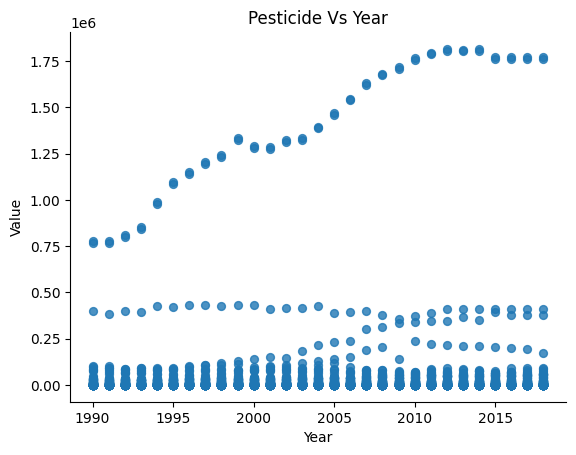

In [8]:
# @title Year vs Value

from matplotlib import pyplot as plt
pest_df.plot(kind='scatter', x='Year', y='Value', s=32, alpha=.8 , title="Pesticide Vs Year")
plt.gca().spines[['top', 'right',]].set_visible(False)

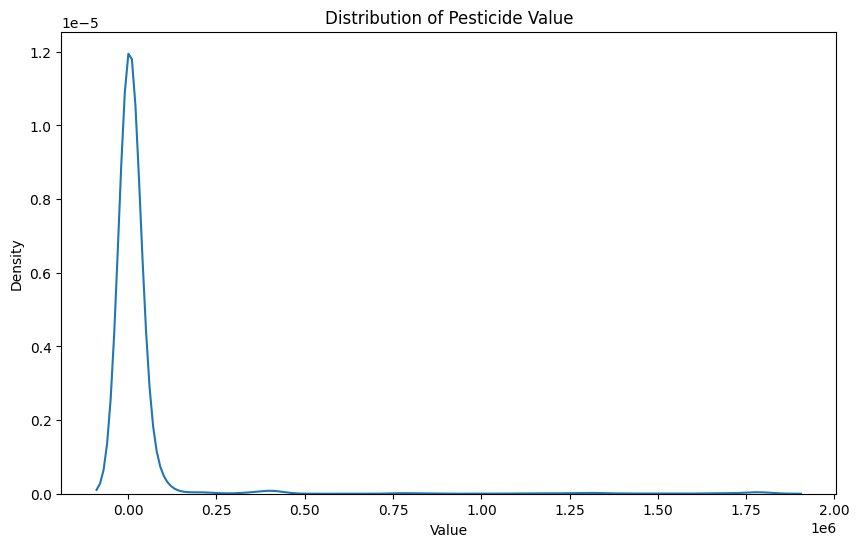

In [9]:
# prompt: plot value as kde plot from pest_df dataframe

import seaborn as sns
plt.figure(figsize=(10,6))
sns.kdeplot(pest_df['Value'])
plt.title('Distribution of Pesticide Value')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [10]:
pest_df.rename(columns={'Value': 'Pesticide'},inplace=True)

## Rainfall

In [11]:
rain_df = pd.read_csv('/content/drive/MyDrive/Classroom/CS546-2025/rainfall.csv')
rain_df.head()

,Unnamed: 0,Rainfall - (MM),Year,Statistics,Country,ISO3
0,0,55.7448,1901,Jan Average,Afghanistan,AFG
1,1,13.9480,1901,Feb Average,Afghanistan,AFG
2,2,43.8464,1901,Mar Average,Afghanistan,AFG
3,3,26.9610,1901,Apr Average,Afghanistan,AFG
4,4,52.9579,1901,May Average,Afghanistan,AFG


In [12]:
# prompt: do a group by on country and then on year and givve me avg of "Rainfall - (MM)' column from rain_df dataframe then add this avg in its correct place

# Calculate the average rainfall for each country and year
avg_rain_df = rain_df.groupby(['Country', 'Year'])['Rainfall - (MM)'].mean().reset_index()

# Rename the 'Rainfall - (MM)' column to 'Avg Rainfall'
avg_rain_df.rename(columns={'Rainfall - (MM)': 'Avg Rainfall'}, inplace=True)

# Merge the average rainfall data back into the original dataframe
rain_df = pd.merge(rain_df, avg_rain_df, on=['Country', 'Year'], how='left')

In [13]:
print(rain_df['Avg Rainfall'].describe())

count    272832.000000
mean        103.470868
std          79.733228
min           0.291037
25%          45.409890
50%          86.110804
75%         145.222906
max         782.373333
Name: Avg Rainfall, dtype: float64


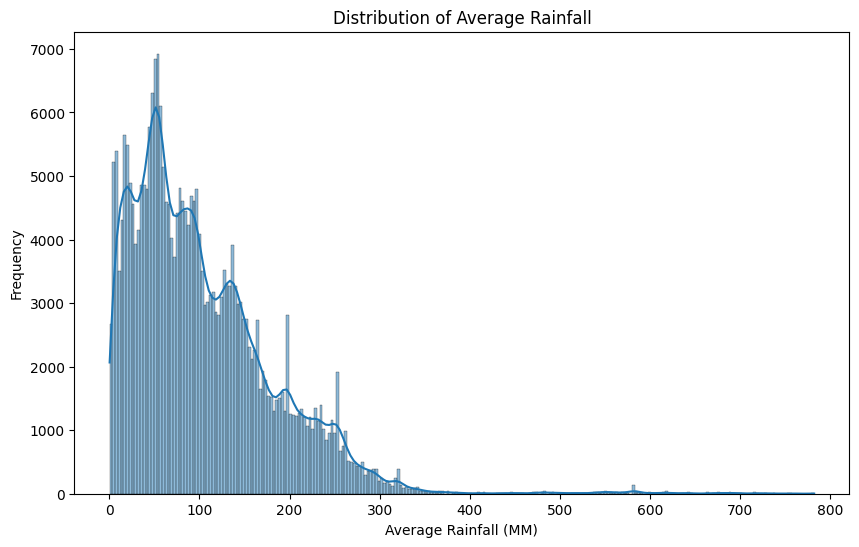

In [14]:
# prompt: do a histogram plot for avg rainfall

plt.figure(figsize=(10, 6))
sns.histplot(rain_df['Avg Rainfall'], kde=True)
plt.title('Distribution of Average Rainfall')
plt.xlabel('Average Rainfall (MM)')
plt.ylabel('Frequency')
plt.show()

In [15]:
rain_df.drop(columns=['Unnamed: 0', 'Statistics', 'Rainfall - (MM)'], inplace=True)
print(rain_df.shape)
rain_df

(272832, 4)


,Year,Country,ISO3,Avg Rainfall
0,1901,Afghanistan,AFG,20.910303
1,1901,Afghanistan,AFG,20.910303
2,1901,Afghanistan,AFG,20.910303
3,1901,Afghanistan,AFG,20.910303
4,1901,Afghanistan,AFG,20.910303
...,...,...,...,...
272827,2016,Zimbabwe,ZWE,37.927746
272828,2016,Zimbabwe,ZWE,37.927746
272829,2016,Zimbabwe,ZWE,37.927746
272830,2016,Zimbabwe,ZWE,37.927746


## Temperature

In [16]:
temp_df = pd.read_csv('/content/drive/MyDrive/Classroom/CS546-2025/temperature.csv')
temp_df

,Unnamed: 0,Temperature - (Celsius),Year,Statistics,Country,ISO3
0,0,-0.03780,1901,Jan Average,Afghanistan,AFG
1,1,2.42348,1901,Feb Average,Afghanistan,AFG
2,2,9.36230,1901,Mar Average,Afghanistan,AFG
3,3,13.55640,1901,Apr Average,Afghanistan,AFG
4,4,18.15090,1901,May Average,Afghanistan,AFG
...,...,...,...,...,...,...
272827,272827,18.75550,2016,Aug Average,Zimbabwe,ZWE
272828,272828,22.99190,2016,Sep Average,Zimbabwe,ZWE
272829,272829,25.86640,2016,Oct Average,Zimbabwe,ZWE
272830,272830,25.85150,2016,Nov Average,Zimbabwe,ZWE


In [17]:
# prompt: do a group by on country and then on year and givve me avg of  tempfall - (MM)' column from temp_df dataframe then add this avg in its correct place

# Calculate the average tempfall for each country and year
avg_temp_df = temp_df.groupby(['Country', 'Year'])['Temperature - (Celsius)'].mean().reset_index()

# Rename the 'Temperature - (Celsius)' column to 'Avg temp'
avg_temp_df.rename(columns={'Temperature - (Celsius)': 'Avg temp'}, inplace=True)

# Merge the average temp data back into the original dataframe
temp_df = pd.merge(temp_df, avg_temp_df, on=['Country', 'Year'], how='left')
temp_df

,Unnamed: 0,Temperature - (Celsius),Year,Statistics,Country,ISO3,Avg temp
0,0,-0.03780,1901,Jan Average,Afghanistan,AFG,13.172872
1,1,2.42348,1901,Feb Average,Afghanistan,AFG,13.172872
2,2,9.36230,1901,Mar Average,Afghanistan,AFG,13.172872
3,3,13.55640,1901,Apr Average,Afghanistan,AFG,13.172872
4,4,18.15090,1901,May Average,Afghanistan,AFG,13.172872
...,...,...,...,...,...,...,...
272827,272827,18.75550,2016,Aug Average,Zimbabwe,ZWE,22.310167
272828,272828,22.99190,2016,Sep Average,Zimbabwe,ZWE,22.310167
272829,272829,25.86640,2016,Oct Average,Zimbabwe,ZWE,22.310167
272830,272830,25.85150,2016,Nov Average,Zimbabwe,ZWE,22.310167


In [18]:
temp_df.drop(columns=['Unnamed: 0', 'Statistics', 'Temperature - (Celsius)'], inplace=True)
print(temp_df.shape)
temp_df

(272832, 4)


,Year,Country,ISO3,Avg temp
0,1901,Afghanistan,AFG,13.172872
1,1901,Afghanistan,AFG,13.172872
2,1901,Afghanistan,AFG,13.172872
3,1901,Afghanistan,AFG,13.172872
4,1901,Afghanistan,AFG,13.172872
...,...,...,...,...
272827,2016,Zimbabwe,ZWE,22.310167
272828,2016,Zimbabwe,ZWE,22.310167
272829,2016,Zimbabwe,ZWE,22.310167
272830,2016,Zimbabwe,ZWE,22.310167


## Yield

In [19]:
yield_df = pd.read_csv('/content/drive/MyDrive/Classroom/CS546-2025/yield.csv')
yield_df

,Unnamed: 0,Domain,Area,Element,Item,Year,Unit,Value
0,0,Crops,Afghanistan,Yield,Barley,1961,hg/ha,10800
1,1,Crops,Afghanistan,Yield,Barley,1962,hg/ha,10800
2,2,Crops,Afghanistan,Yield,Barley,1963,hg/ha,10800
3,3,Crops,Afghanistan,Yield,Barley,1964,hg/ha,10857
4,4,Crops,Afghanistan,Yield,Barley,1965,hg/ha,10857
...,...,...,...,...,...,...,...,...
63686,63686,Crops,Zimbabwe,Yield,Wheat,2015,hg/ha,20486
63687,63687,Crops,Zimbabwe,Yield,Wheat,2016,hg/ha,19013
63688,63688,Crops,Zimbabwe,Yield,Wheat,2017,hg/ha,17542
63689,63689,Crops,Zimbabwe,Yield,Wheat,2018,hg/ha,16379


In [20]:
yield_df.drop(columns=['Unnamed: 0', 'Domain','Element', 'Unit'], inplace=True)
yield_df.rename(columns={'Value': 'Yield'},inplace=True)
print(yield_df.columns )
yield_df

Index(['Area', 'Item', 'Year', 'Yield'], dtype='object')


,Area,Item,Year,Yield
0,Afghanistan,Barley,1961,10800
1,Afghanistan,Barley,1962,10800
2,Afghanistan,Barley,1963,10800
3,Afghanistan,Barley,1964,10857
4,Afghanistan,Barley,1965,10857
...,...,...,...,...
63686,Zimbabwe,Wheat,2015,20486
63687,Zimbabwe,Wheat,2016,19013
63688,Zimbabwe,Wheat,2017,17542
63689,Zimbabwe,Wheat,2018,16379


## Combining df's

### pest and yield

In [21]:
print(pest_df.columns)
print(yield_df.columns)

Index(['Area', 'Year', 'Pesticide'], dtype='object')
Index(['Area', 'Item', 'Year', 'Yield'], dtype='object')


In [22]:
# prompt: join the two dataframe in the previous cell using area, and year as key

# Merge pest_df and yield_df based on 'Area' and 'Year'
merged_df = pd.merge(pest_df, yield_df, on=['Area', 'Year'], how='inner')
merged_df

,Area,Year,Pesticide,Item,Yield
0,Albania,1990,121,Barley,10000
1,Albania,1990,121,Carrots and turnips,150000
2,Albania,1990,121,Cauliflowers and broccoli,171429
3,Albania,1990,121,Garlic,65000
4,Albania,1990,121,Maize,36613
...,...,...,...,...,...
32552,Zimbabwe,2018,2185,Maize,13506
32553,Zimbabwe,2018,2185,Oats,20480
32554,Zimbabwe,2018,2185,Potatoes,41551
32555,Zimbabwe,2018,2185,Sweet potatoes,28020


In [23]:
print("NA\n")
print(merged_df.isna().sum())
print("\nnan\n")
print(merged_df.isnull().sum())

NA

Area         0
Year         0
Pesticide    0
Item         0
Yield        0
dtype: int64

nan

Area         0
Year         0
Pesticide    0
Item         0
Yield        0
dtype: int64


In [24]:
# prompt: print the no of unique values in each column and the uniques values themselves

for col in merged_df.columns:
    unique_values = merged_df[col].unique()
    num_unique = len(unique_values)
    print(f"Column '{col}': {num_unique} unique values")
    print(unique_values)
    print("---")

Column 'Area': 168 unique values
['Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belgium-Luxembourg' 'Belize' 'Bhutan'
 'Bolivia (Plurinational State of)' 'Botswana' 'Brazil'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China'
 'China, Hong Kong SAR' 'China, mainland' 'China, Taiwan Province of'
 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Côte d'Ivoire"
 'Croatia' 'Cyprus' 'Czechia' 'Denmark' 'Dominican Republic' 'Ecuador'
 'Egypt' 'El Salvador' 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland'
 'France' 'French Polynesia' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran (Islamic Republic of)'
 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jorda

### rainfall and temperature

In [25]:
print(rain_df.columns)
print(temp_df.columns)

Index(['Year', 'Country', 'ISO3', 'Avg Rainfall'], dtype='object')
Index(['Year', 'Country', 'ISO3', 'Avg temp'], dtype='object')


In [26]:
merged2_df = pd.merge(rain_df, temp_df, on=['Country', 'Year'], how='inner')
merged2_df.drop(columns=['ISO3_x','ISO3_y'], inplace=True)
merged2_df

,Year,Country,Avg Rainfall,Avg temp
0,1901,Afghanistan,20.910303,13.172872
1,1901,Afghanistan,20.910303,13.172872
2,1901,Afghanistan,20.910303,13.172872
3,1901,Afghanistan,20.910303,13.172872
4,1901,Afghanistan,20.910303,13.172872
...,...,...,...,...
3273979,2016,Zimbabwe,37.927746,22.310167
3273980,2016,Zimbabwe,37.927746,22.310167
3273981,2016,Zimbabwe,37.927746,22.310167
3273982,2016,Zimbabwe,37.927746,22.310167


In [27]:
print("NA\n")
print(merged2_df.isna().sum())
print("\nnan\n")
print(merged2_df.isnull().sum())

print("\n\n\n\n")

for col in merged2_df.columns:
    unique_values = merged2_df[col].unique()
    num_unique = len(unique_values)
    print(f"Column '{col}': {num_unique} unique values")
    print(unique_values)
    print("---")

NA

Year            0
Country         0
Avg Rainfall    0
Avg temp        0
dtype: int64

nan

Year            0
Country         0
Avg Rainfall    0
Avg temp        0
dtype: int64





Column 'Year': 116 unique values
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910 1911 1912 1913 1914
 1915 1916 1917 1918 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928
 1929 1930 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942
 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956
 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016]
---
Column 'Country': 196 unique values
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'The Bahamas' 'Ba

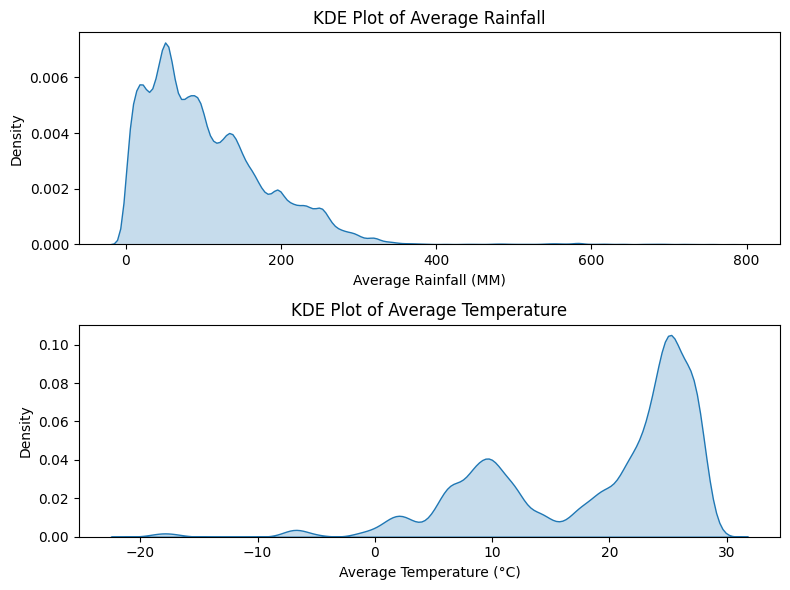

In [28]:
# prompt: plot the kde plots for abg rainfall and avg temp , in to differnt subplots in vertical mannar


plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
sns.kdeplot(rain_df['Avg Rainfall'], shade=True)
plt.title('KDE Plot of Average Rainfall')
plt.xlabel('Average Rainfall (MM)')

plt.subplot(2, 1, 2)
sns.kdeplot(temp_df['Avg temp'], shade=True)
plt.title('KDE Plot of Average Temperature')
plt.xlabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

### Combining the two merged dataframes

In [29]:
merged_df.rename(columns={'Area': 'Country'}, inplace=True)
print(merged_df.columns)
print(merged2_df.columns)

Index(['Country', 'Year', 'Pesticide', 'Item', 'Yield'], dtype='object')
Index(['Year', 'Country', 'Avg Rainfall', 'Avg temp'], dtype='object')


In [30]:
# final_merged_df = pd.merge(merged_df, merged2_df, on=['Country', 'Year'], how='outer')
# print(final_merged_df.shape)
# print(final_merged_df.isna().sum())
# final_merged_df

In [31]:
# final_merged_df.dropna(inplace=True)
# print(final_merged_df.shape)
# print(final_merged_df.isna().sum())
# final_merged_df

In [32]:
final_merged_df = pd.merge(merged_df, merged2_df, on=['Country', 'Year'], how='inner')
print(final_merged_df.shape)
print(final_merged_df.isna().sum())
final_merged_df

(3632976, 7)
Country         0
Year            0
Pesticide       0
Item            0
Yield           0
Avg Rainfall    0
Avg temp        0
dtype: int64


,Country,Year,Pesticide,Item,Yield,Avg Rainfall,Avg temp
0,Albania,1990,121,Barley,10000,67.686208,12.051221
1,Albania,1990,121,Barley,10000,67.686208,12.051221
2,Albania,1990,121,Barley,10000,67.686208,12.051221
3,Albania,1990,121,Barley,10000,67.686208,12.051221
4,Albania,1990,121,Barley,10000,67.686208,12.051221
...,...,...,...,...,...,...,...
3632971,Zimbabwe,2016,2185,Wheat,19013,37.927746,22.310167
3632972,Zimbabwe,2016,2185,Wheat,19013,37.927746,22.310167
3632973,Zimbabwe,2016,2185,Wheat,19013,37.927746,22.310167
3632974,Zimbabwe,2016,2185,Wheat,19013,37.927746,22.310167


In [33]:
for col in final_merged_df.columns:
    unique_values = final_merged_df[col].unique()
    num_unique = len(unique_values)
    print(f"Column '{col}': {num_unique} unique values")
    print(unique_values)
    print("---")

Column 'Country': 135 unique values
['Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Bhutan' 'Botswana' 'Brazil' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cameroon' 'Canada' 'Central African Republic'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Costa Rica' 'Croatia'
 'Cyprus' 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gambia'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guinea-Bissau'
 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kuwait' 'Kyrgyzstan' 'Latvia' 'Lebanon' 'Lesotho' 'Libya'
 'Lithuania' 'Luxembourg' 'Madagascar' 'Malawi' 'Malaysia' 'Maldives'
 'Mali' 'Malta' 'Mauritania' 'Mauritius' 'Mexico' 'Mongolia' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherla

In [34]:
# prompt: do kde plots for all numeric columns in the dataframe as individual subplots and frequency plots for categorical columns of final_merged_df

def create_kde_plots(df, numeric_cols):
    num_plots = len(numeric_cols)
    num_rows = (num_plots + 2) // 3
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols):
        sns.kdeplot(df[col], ax=axes[i], shade=True)
        axes[i].set_title(f'KDE Plot of {col}')
        axes[i].set_xlabel(col)


    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# Function to create frequency plots for categorical columns
def create_frequency_plots(df, categorical_cols):
    for col in categorical_cols:
        plt.figure(figsize=(8, 6))
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Frequency Plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
        plt.tight_layout()
        plt.show()


# Identify numeric and categorical columns
numeric_cols = final_merged_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = final_merged_df.select_dtypes(include=['object', 'category']).columns.tolist()


# # Create KDE plots for numeric columns
# create_kde_plots(final_merged_df, numeric_cols)

# # Create frequency plots for categorical columns
# create_frequency_plots(final_merged_df, categorical_cols)

tried the joins in two ways outer and inner. In outer join after removing the rows with null/Nan values the shape of dataframe is same as inner join so i will use the inner join and skip some preprocessing of outher join

# Regression Model Building

In [35]:
print(final_merged_df.columns)
print(final_merged_df.describe())
print(final_merged_df.info())

Index(['Country', 'Year', 'Pesticide', 'Item', 'Yield', 'Avg Rainfall',
       'Avg temp'],
      dtype='object')
               Year     Pesticide         Yield  Avg Rainfall      Avg temp
count  3.632976e+06  3.632976e+06  3.632976e+06  3.632976e+06  3.632976e+06
mean   2.003375e+03  3.494096e+04  9.514574e+04  8.111538e+01  1.668824e+01
std    7.681824e+00  1.750279e+05  1.059929e+05  6.010298e+01  8.008592e+00
min    1.990000e+03  0.000000e+00  0.000000e+00  1.391968e+00 -7.166322e+00
25%    1.997000e+03  5.670000e+02  2.080800e+04  4.050942e+01  9.981922e+00
50%    2.003000e+03  2.803000e+03  5.444700e+04  6.306320e+01  1.822247e+01
75%    2.010000e+03  1.375600e+04  1.343930e+05  1.122935e+02  2.399241e+01
max    2.016000e+03  1.815690e+06  1.705000e+06  4.166405e+02  2.954108e+01
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3632976 entries, 0 to 3632975
Data columns (total 7 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Country       object 
 1   Year

## Preping data for training

In [36]:
X= final_merged_df.drop(columns=['Yield'])
y= final_merged_df['Yield']

**Year** : Handling this by converting it to standardizing, embedding or one-hot encoding


### Tring Year as numerical feature

In [47]:
categorical_features = ["Country", "Item"]
numerical_features = ["Year", "Pesticide", "Avg Rainfall", "Avg temp"]

# Preprocessing for numerical data
numerical_transformer = StandardScaler()

# Preprocessing for categorical data
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [48]:
X_preprocessed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

In [49]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    # Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)  # Single output for regression
])


In [50]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [51]:
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
  2261/363298 ━━━━━━━━━━━━━━━━━━━━ 1:03:14 11ms/step - loss: 9961799680.0000 - mae: 63427.2266

KeyboardInterrupt: 

In [ ]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Mean Absolute Error: {mae:.2f}")